# ___Compare how the definition of `fine roots` affect `hOUwie` results___
------------------------------

In [1]:
!python --version

Python 3.14.6


The system cannot find the path specified.


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from scipy.stats import pearsonr, f_oneway

In [3]:
COLLABORATION_GRADIENT_TRAITS = [
    "F00679", # RD
    "F00727", # SRL
]

CONSERVATION_GRADIENT_TRAITS = [
    "F00709", # RTD
]

CHOSEN_ROOT_TRAITS = COLLABORATION_GRADIENT_TRAITS + CONSERVATION_GRADIENT_TRAITS

CHOSEN_TRAITS_DICT = {
    "F00709":  "RTD",
    "F00679":  "RD",
    "F00727":  "SRL"
}

PLANT_TAXONOMY_ACCEPTED_COLUMNS = [
    "F01286", # Genus of plant according to The Plant List
    "F01287", # Species epithet of plant according to The Plant List
    "F01289", # Family of plant according to The Plant List
    "F01290"  # Order of plant.
]

BINOMINAL_NAME = ["F01286", "F01287"]

BINOMINAL_NAME_DATA_SOURCE = ["F00018", "F00019"]

In [34]:
fred = pd.read_csv(r"../../data/chapter2/FRED/FRED4_Entire_Database_2026.csv", low_memory=False, header=0, skiprows=range(1, 7), encoding="latin1") # FRED 4.0
meta = pd.read_csv(r"../../data/chapter2/FRED/FRED3_Column_Definitions_2021.csv", usecols=["column_id", "name", "units"], index_col="column_id")

fred.dropna(subset=BINOMINAL_NAME, inplace=True)

fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS] = fred.loc[:, PLANT_TAXONOMY_ACCEPTED_COLUMNS].apply(lambda col: col.str.strip()) # strip off all the unnecessary spaces

fred = pd.concat([fred, fred.F01286 + ' ' + fred.F01287], axis=1)
fred.rename({0: "binominal"}, axis=1, inplace=True)

# let's hope that the new subsets are subsets of the 1301 species subset - I cba to do a taxonomic cleanup again for these two now

lookup = pd.read_excel("../../data/chapter2/FRED/subsets/final.xlsx", sheet_name="final", usecols=["binominal", "F01286", "F01289", "state", "synonym"])

In [19]:
# the critical point here is that we don't want any differences in the sampled species between the two groups
# else we cannot attribute the potential variances to differences in the continuous trait values
# so first pick the intersect of species that has RD < 2.00 and root order <= 3; then group them based on individual criteria

In [20]:
# species that have records under both criteria - RD <= 2.000 and ORDER <= 3

species = fred.loc[:, ["binominal"] + BINOMINAL_NAME + [*CHOSEN_ROOT_TRAITS, "F00056"]].dropna().query("F00056<=3 and F00679<=2.00").binominal.unique()
species

<StringArray>
[          'Larix gmelinii',     'Fraxinus mandshurica',
      'Populus trichocarpa',          'Populus tremula',
    'Cinnamomum micranthum',           'Magnolia odora',
  'Cinnamomum chekiangense',        'Castanopsis fabri',
   'Liquidambar gracilipes',     'Castanopsis carlesii',
 ...
       'Dacrydium balansae',              'Nageia nagi',
         'Dioon rzedowskii',     'Encephalartos gratus',
           'Zamia lucayana',   'Chamaecyparis pisifera',
        'Ephedra distachya',              'Picea abies',
           'Pinus resinosa', 'Sciadopitys verticillata']
Length: 403, dtype: str

In [21]:
# RD <= 2.00 mm subset

diameter_subset = fred.loc[:, ["binominal"] + BINOMINAL_NAME + [*CHOSEN_ROOT_TRAITS, "F00056"]].dropna().query("binominal.isin(@species) and F00679<=2.00").reset_index(drop=True)
diameter_subset

,binominal,F01286,F01287,F00679,F00727,F00709,F00056
0,Larix gmelinii,Larix,gmelinii,0.319412,32.211568,0.354286,1.0
1,Larix gmelinii,Larix,gmelinii,0.411555,25.480815,0.294286,2.0
2,Larix gmelinii,Larix,gmelinii,0.527621,12.980828,0.382857,3.0
3,Larix gmelinii,Larix,gmelinii,0.846975,6.250067,0.334286,4.0
4,Larix gmelinii,Larix,gmelinii,0.307450,34.615414,0.382857,1.0
...,...,...,...,...,...,...,...
1628,Cephalotaxus harringtonii,Cephalotaxus,harringtonii,0.553668,19.908196,0.160519,2.0
1629,Cephalotaxus harringtonii,Cephalotaxus,harringtonii,0.641848,7.373034,0.350667,3.0
1630,Taxus cuspidata,Taxus,cuspidata,0.543465,33.296519,0.138632,1.0
1631,Taxus cuspidata,Taxus,cuspidata,0.520440,26.052343,0.161375,2.0


In [22]:
# ORDER <= 3 subset

order_subset = fred.loc[:, ["binominal"] + BINOMINAL_NAME + [*CHOSEN_ROOT_TRAITS, "F00056"]].dropna().query("binominal.isin(@species) and F00056<=3").reset_index(drop=True)
order_subset

,binominal,F01286,F01287,F00679,F00727,F00709,F00056
0,Larix gmelinii,Larix,gmelinii,0.319412,32.211568,0.354286,1.0
1,Larix gmelinii,Larix,gmelinii,0.411555,25.480815,0.294286,2.0
2,Larix gmelinii,Larix,gmelinii,0.527621,12.980828,0.382857,3.0
3,Larix gmelinii,Larix,gmelinii,0.307450,34.615414,0.382857,1.0
4,Larix gmelinii,Larix,gmelinii,0.459401,26.442353,0.260000,2.0
...,...,...,...,...,...,...,...
1253,Cephalotaxus harringtonii,Cephalotaxus,harringtonii,0.553668,19.908196,0.160519,2.0
1254,Cephalotaxus harringtonii,Cephalotaxus,harringtonii,0.641848,7.373034,0.350667,3.0
1255,Taxus cuspidata,Taxus,cuspidata,0.543465,33.296519,0.138632,1.0
1256,Taxus cuspidata,Taxus,cuspidata,0.520440,26.052343,0.161375,2.0


In [23]:
assert np.setdiff1d(diameter_subset.binominal.unique(), order_subset.binominal.unique()).size == 0 # species in both groups must be identical

In [24]:
diameter_subset.groupby("binominal", as_index=False).agg({t: "mean" for t in CHOSEN_ROOT_TRAITS})

,binominal,F00679,F00727,F00709
0,Abies nephrolepis,0.415233,27.045857,0.279706
1,Acacia auriculiformis,0.491117,37.353333,0.293333
2,Acacia crassicarpa,0.225930,108.280000,0.360000
3,Acacia mangium,0.252550,99.190000,0.290000
4,Acer barbinerve,0.252300,143.678973,0.152829
...,...,...,...,...
398,Vitis amurensis,0.275050,104.011337,0.173365
399,Wendlandia uvariifolia,0.224170,45.270000,0.430000
400,Wurfbainia villosa,0.231956,187.404807,0.133169
401,Zabelia biflora,0.529200,30.947057,0.146696


In [25]:
order_subset.groupby("binominal", as_index=False).agg({t: "mean" for t in CHOSEN_ROOT_TRAITS})

,binominal,F00679,F00727,F00709
0,Abies nephrolepis,0.415233,27.045857,0.279706
1,Acacia auriculiformis,0.385370,53.822500,0.270000
2,Acacia crassicarpa,0.225930,108.280000,0.360000
3,Acacia mangium,0.252550,99.190000,0.290000
4,Acer barbinerve,0.252300,143.678973,0.152829
...,...,...,...,...
398,Vitis amurensis,0.275050,104.011337,0.173365
399,Wendlandia uvariifolia,0.224170,45.270000,0.430000
400,Wurfbainia villosa,0.231956,187.404807,0.133169
401,Zabelia biflora,0.529200,30.947057,0.146696


In [26]:
subset = pd.merge(left=diameter_subset.groupby("binominal", as_index=False).agg({t: "mean" for t in CHOSEN_ROOT_TRAITS}), left_on="binominal",
                  right=order_subset.groupby("binominal", as_index=False).agg({t: "mean" for t in CHOSEN_ROOT_TRAITS}), right_on="binominal",
                  suffixes=('D', 'O'), how="inner") # D - diamater, O - root order
subset

,binominal,F00679D,F00727D,F00709D,F00679O,F00727O,F00709O
0,Abies nephrolepis,0.415233,27.045857,0.279706,0.415233,27.045857,0.279706
1,Acacia auriculiformis,0.491117,37.353333,0.293333,0.385370,53.822500,0.270000
2,Acacia crassicarpa,0.225930,108.280000,0.360000,0.225930,108.280000,0.360000
3,Acacia mangium,0.252550,99.190000,0.290000,0.252550,99.190000,0.290000
4,Acer barbinerve,0.252300,143.678973,0.152829,0.252300,143.678973,0.152829
...,...,...,...,...,...,...,...
398,Vitis amurensis,0.275050,104.011337,0.173365,0.275050,104.011337,0.173365
399,Wendlandia uvariifolia,0.224170,45.270000,0.430000,0.224170,45.270000,0.430000
400,Wurfbainia villosa,0.231956,187.404807,0.133169,0.231956,187.404807,0.133169
401,Zabelia biflora,0.529200,30.947057,0.146696,0.529200,30.947057,0.146696


In [28]:
pearsonr(subset.F00679D, subset.F00679O) # RD

PearsonRResult(statistic=np.float64(0.9456261060998297), pvalue=np.float64(1.0627698961794227e-197))

In [29]:
pearsonr(subset.F00727D, subset.F00727O) # SRL

PearsonRResult(statistic=np.float64(0.9896708091753537), pvalue=np.float64(0.0))

In [30]:
pearsonr(subset.F00709D, subset.F00709O) # RTD

PearsonRResult(statistic=np.float64(0.9480502729866637), pvalue=np.float64(1.4535241511098146e-201))

In [92]:
# prepare this for hOUwie model fits

In [150]:
np.setdiff1d(subset.binominal, lookup.binominal).size # let's cherrypick the species we can get state data from the old subset

2

In [151]:
subset.query("binominal.isin(@lookup.binominal)")

,binominal,F00679D,F00727D,F00709D,F00679O,F00727O,F00709O
0,Abies nephrolepis,0.415233,27.045857,0.279706,0.415233,27.045857,0.279706
1,Acacia auriculiformis,0.491117,37.353333,0.293333,0.385370,53.822500,0.270000
2,Acacia crassicarpa,0.225930,108.280000,0.360000,0.225930,108.280000,0.360000
3,Acacia mangium,0.252550,99.190000,0.290000,0.252550,99.190000,0.290000
4,Acer barbinerve,0.252300,143.678973,0.152829,0.252300,143.678973,0.152829
...,...,...,...,...,...,...,...
398,Vitis amurensis,0.275050,104.011337,0.173365,0.275050,104.011337,0.173365
399,Wendlandia uvariifolia,0.224170,45.270000,0.430000,0.224170,45.270000,0.430000
400,Wurfbainia villosa,0.231956,187.404807,0.133169,0.231956,187.404807,0.133169
401,Zabelia biflora,0.529200,30.947057,0.146696,0.529200,30.947057,0.146696


In [35]:
subset_v2 = pd.merge(left=subset.query("binominal.isin(@lookup.binominal)"), left_on="binominal", right=lookup, right_on="binominal", how="left")
subset_v2

,binominal,F00679D,F00727D,F00709D,F00679O,F00727O,F00709O,F01286,F01289,state,synonym
0,Abies nephrolepis,0.415233,27.045857,0.279706,0.415233,27.045857,0.279706,Abies,Pinaceae,EcM,"('Abies veitchii var. nephrolepis', 'Abies sib..."
1,Acacia auriculiformis,0.491117,37.353333,0.293333,0.385370,53.822500,0.270000,Acacia,Fabaceae,EcMAM,"('Racosperma auriculiforme',)"
2,Acacia crassicarpa,0.225930,108.280000,0.360000,0.225930,108.280000,0.360000,Acacia,Fabaceae,EcMAM,"('Racosperma crassicarpum',)"
3,Acacia mangium,0.252550,99.190000,0.290000,0.252550,99.190000,0.290000,Acacia,Fabaceae,EcMAM,"('Racosperma mangium',)"
4,Acer barbinerve,0.252300,143.678973,0.152829,0.252300,143.678973,0.152829,Acer,Sapindaceae,AM,"('Acer diabolicum subsp. barbinerve',)"
...,...,...,...,...,...,...,...,...,...,...,...
396,Vitis amurensis,0.275050,104.011337,0.173365,0.275050,104.011337,0.173365,Vitis,Vitaceae,AM,"('Vitis vinifera f. amurensis', 'Vitis vulpina..."
397,Wendlandia uvariifolia,0.224170,45.270000,0.430000,0.224170,45.270000,0.430000,Wendlandia,Rubiaceae,AM,NaN
398,Wurfbainia villosa,0.231956,187.404807,0.133169,0.231956,187.404807,0.133169,Wurfbainia,Zingiberaceae,AM,"('Cardamomum villosum', 'Elettaria villosa', '..."
399,Zabelia biflora,0.529200,30.947057,0.146696,0.529200,30.947057,0.146696,Zabelia,Caprifoliaceae,AM,"('Abelia biflora',)"


In [36]:
STATE_COLOURS = pd.Series({"AM": "#E7BC0C", "EcM": "#23B9AF", "ErM": "#6B6CF2", "NM": "#11E823", "NMAM": "#2D2E30", "EcMAM": "#E71A23"})
STATE_COLOURS

AM       #E7BC0C
EcM      #23B9AF
ErM      #6B6CF2
NM       #11E823
NMAM     #2D2E30
EcMAM    #E71A23
dtype: str

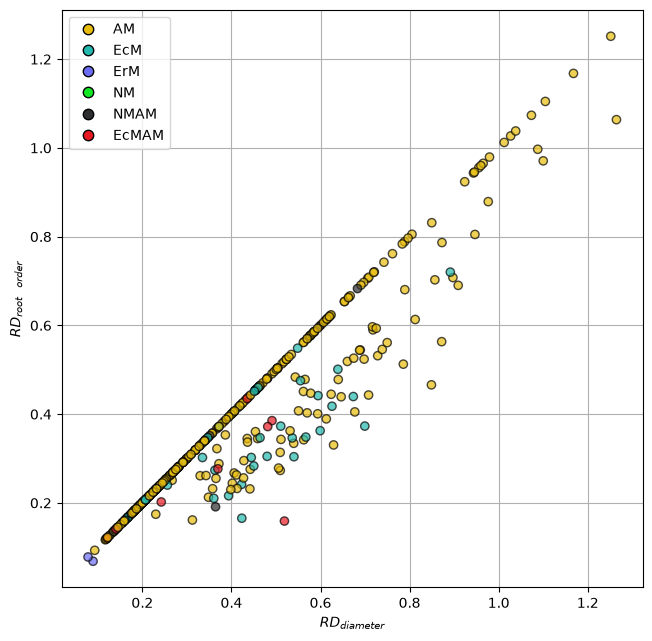

In [37]:
fig, axes = plt.subplots()

fig.set_size_inches(7.5, 7.5)
axes.scatter(x = subset_v2.F00679D, y = subset_v2.F00679O, c=STATE_COLOURS[subset_v2.state], ec="black", alpha=0.7)
axes.grid()
axes.set_axisbelow(True)
axes.set_xlabel(r"$RD_{diameter}$")
axes.set_ylabel(r"$RD_{root\hspace{1}order}$")
axes.legend(handles=[Line2D([0], [0], marker='o', markeredgecolor="black", label=state, markerfacecolor=col, markersize=7.5, linestyle="none") for (state, col) in STATE_COLOURS.items()])

plt.show()

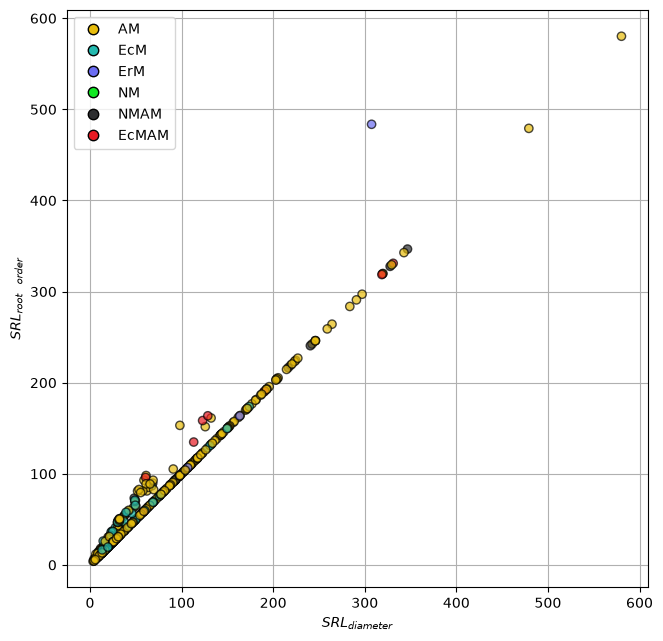

In [38]:
fig, axes = plt.subplots()

fig.set_size_inches(7.5, 7.5)
axes.scatter(x = subset_v2.F00727D, y = subset_v2.F00727O, c=STATE_COLOURS[subset_v2.state], ec="black", alpha=0.7)
axes.grid()
axes.set_axisbelow(True)
axes.set_xlabel(r"$SRL_{diameter}$")
axes.set_ylabel(r"$SRL_{root\hspace{1}order}$")
axes.legend(handles=[Line2D([0], [0], marker='o', markeredgecolor="black", label=state, markerfacecolor=col, markersize=7.5, linestyle="none") for (state, col) in STATE_COLOURS.items()])

plt.show()

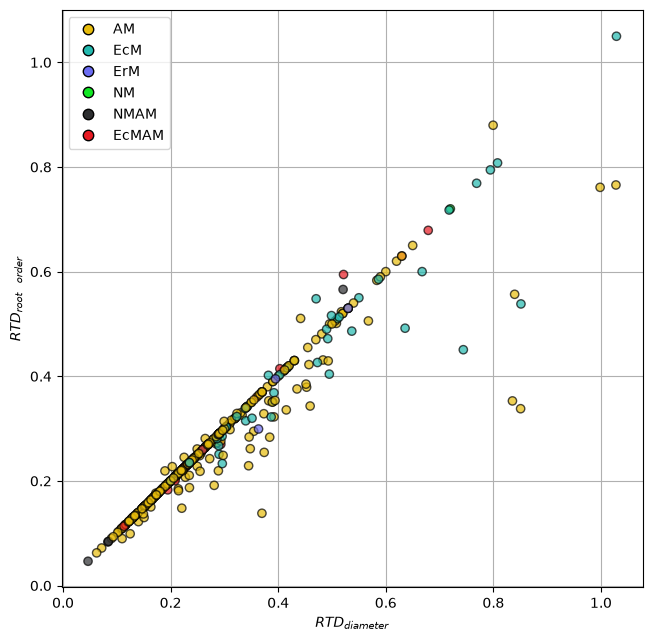

In [39]:
fig, axes = plt.subplots()

fig.set_size_inches(7.5, 7.5)
axes.scatter(x = subset_v2.F00709D, y = subset_v2.F00709O, c=STATE_COLOURS[subset_v2.state], ec="black", alpha=0.7)
axes.grid()
axes.set_axisbelow(True)
axes.set_xlabel(r"$RTD_{diameter}$")
axes.set_ylabel(r"$RTD_{root\hspace{1}order}$")
axes.legend(handles=[Line2D([0], [0], marker='o', markeredgecolor="black", label=state, markerfacecolor=col, markersize=7.5, linestyle="none") for (state, col) in STATE_COLOURS.items()])

plt.show()

In [40]:
subset_v2.head()

,binominal,F00679D,F00727D,F00709D,F00679O,F00727O,F00709O,F01286,F01289,state,synonym
0,Abies nephrolepis,0.415233,27.045857,0.279706,0.415233,27.045857,0.279706,Abies,Pinaceae,EcM,"('Abies veitchii var. nephrolepis', 'Abies sib..."
1,Acacia auriculiformis,0.491117,37.353333,0.293333,0.385370,53.822500,0.270000,Acacia,Fabaceae,EcMAM,"('Racosperma auriculiforme',)"
2,Acacia crassicarpa,0.225930,108.280000,0.360000,0.225930,108.280000,0.360000,Acacia,Fabaceae,EcMAM,"('Racosperma crassicarpum',)"
3,Acacia mangium,0.252550,99.190000,0.290000,0.252550,99.190000,0.290000,Acacia,Fabaceae,EcMAM,"('Racosperma mangium',)"
4,Acer barbinerve,0.252300,143.678973,0.152829,0.252300,143.678973,0.152829,Acer,Sapindaceae,AM,"('Acer diabolicum subsp. barbinerve',)"


In [202]:
subset_v2.iloc[:, range(1, 7)] = subset_v2.iloc[:, range(1, 7)].apply(np.log) # log transform the species averages
subset_v2 = subset_v2.loc[:, ["binominal", "F01286", "F01289", "F00679D", "F00727D", "F00709D", "F00679O", "F00727O", "F00709O", "state", "synonym"]]
subset_v2.to_csv(r"../../data/chapter2/FRED/subsets/fineroot-comparison.csv", index=False)

In [5]:
# examine the hOUwie results for RD

fineroot_subset_rd_comp = pd.read_csv(r"../../data/chapter2/ModelAvgParams_RD_fineroot_criteria_comparison.csv") # these were computed with the force arg set to FALSE
fineroot_subset_rd_comp.head()

,rates,alpha,sigma.sq,theta,expected_mean,expected_var,tip_state,criteria,cd
0,0.000978,1.175671e-10,0.01947,-0.677531,-0.677531,7.606824,AM,RD,True
1,0.000978,1.175671e-10,0.01947,-0.677531,-0.677531,7.606824,AM,RD,True
2,0.000978,1.175671e-10,0.01947,-0.677531,-0.677531,7.606824,AM,RD,True
3,0.000978,1.175671e-10,0.01947,-0.677531,-0.677531,7.606824,AM,RD,True
4,0.000978,1.175671e-10,0.01947,-0.677531,-0.677531,7.606824,AM,RD,True


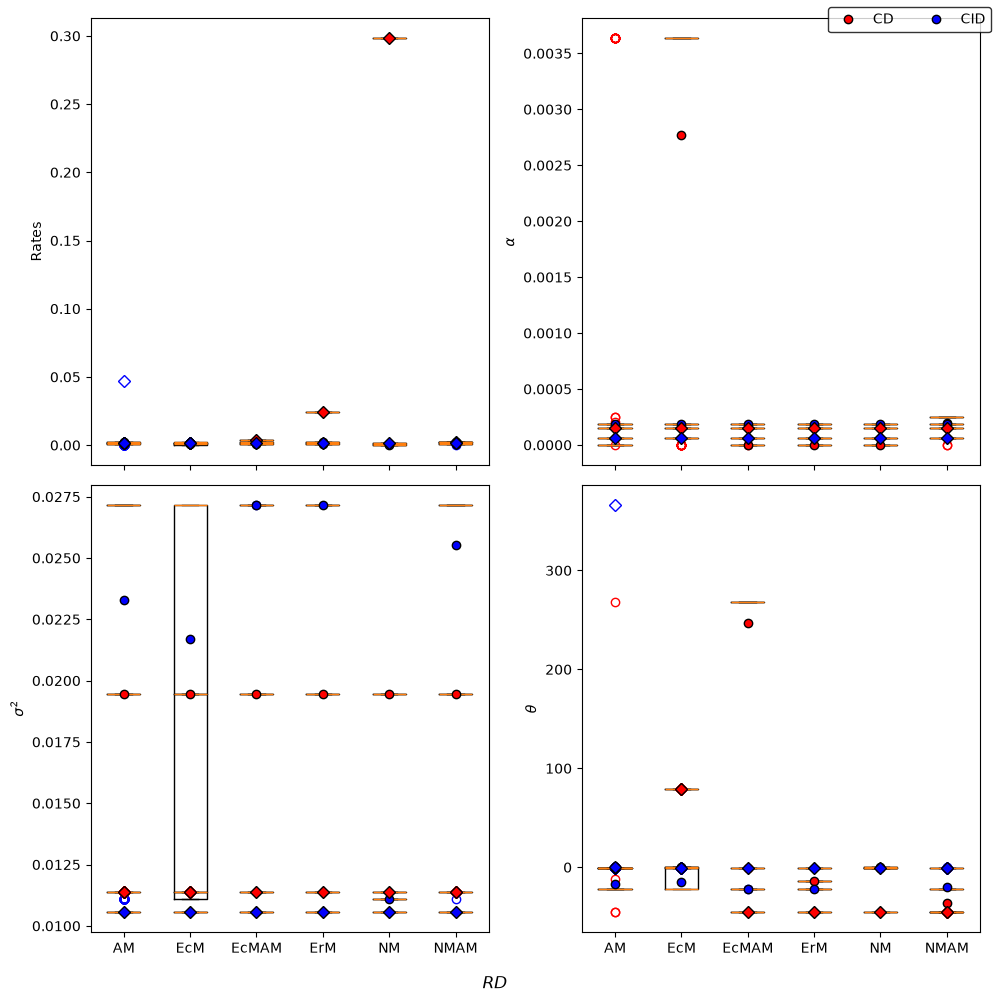

In [45]:
METRICS_AND_LATEX_SYMBOLS = { "rates": "Rates", "alpha": r"$\alpha$", "sigma.sq": r"$\sigma^{2}$", "theta": r"$\theta$" } # LaTex symbols for some of the model estimates

fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=False)
fig.set_size_inches(10, 10)

for crit in ("RD", "ORDER"):

    meanprops_cd = {"marker": 'o' if crit == "RD" else 'D', "markerfacecolor": "red", "markeredgecolor": "black"}
    meanprops_cid = {"marker": 'o' if crit == "RD" else 'D', "markerfacecolor": "blue", "markeredgecolor": "black"}

    flierprops_cd = {'marker': 'o' if crit == "RD" else 'D', 'markerfacecolor': "none", "markeredgecolor": "red"}
    flierprops_cid = {'marker': 'o' if crit == "RD" else 'D', 'markerfacecolor': "none", "markeredgecolor": "blue"}
    
    cdep = fineroot_subset_rd_comp.query(f"criteria=='{crit}' and cd")
    cindep = fineroot_subset_rd_comp.query(f"criteria=='{crit}' and (not cd)")
    
    for (axis, col) in zip(axes.flatten(), METRICS_AND_LATEX_SYMBOLS):

        axis.boxplot([df.loc[:, col] for (_, df) in cdep.groupby("tip_state")], showmeans=True, meanprops=meanprops_cd, flierprops=flierprops_cd)
        axis.boxplot([df.loc[:, col] for (_, df) in cindep.groupby("tip_state")], showmeans=True, meanprops= meanprops_cid, flierprops=flierprops_cid)

        axis.set_xticks(ticks=np.arange(1, fineroot_subset_rd_comp.tip_state.unique().size + 1), labels=[_ for (_, df) in cdep.groupby("tip_state")]) # set it last manually, instead of through axes.boxplot() each time
        axis.set_ylabel(METRICS_AND_LATEX_SYMBOLS.get(col))
        axis.grid()
        axis.set_axisbelow(True)
        
fig.supxlabel(f"$RD$")
fig.legend(edgecolor="black", ncols=2, loc="upper right",
           handles=[Line2D(xdata=[0], ydata=[0], marker='o', markeredgecolor="black", markerfacecolor="red", label="CD", linestyle="none"),
                                                         Line2D(xdata=[0], ydata=[0], marker='o', markeredgecolor="black", markerfacecolor="blue", label="CID", linestyle="none")])
plt.tight_layout()
plt.show()